# Lab 3 Extended: Student Performance Regression Analysis
In this lab, we will fetch a real-world **Student Performance dataset** from the web (UCI Machine Learning Repository). We will perform basic data preprocessing, handle missing values, encode categorical variables, scale features, and build a Linear Regression model.

Finally, we will evaluate the model, visualize the results, and analyze overfitting vs generalization.

In [8]:
import pandas as pd
import numpy as np
import urllib.request
import zipfile
import os

df = pd.read_csv('student/student-mat.csv', sep=';')

# To practice handling missing values, let's randomly inject a few NaNs into some columns
np.random.seed(42)
for col in ['age', 'absences']:
    mask = np.random.rand(len(df)) < 0.05
    df.loc[mask, col] = np.nan

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully!
Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18.0,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6.0,5,6,6
1,GP,F,17.0,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4.0,5,5,6
2,GP,F,15.0,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10.0,7,8,10
3,GP,F,15.0,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2.0,15,14,15
4,GP,F,16.0,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4.0,6,10,10


## 1. Basic Data Preprocessing
- Handle missing values
- Encode categorical variables
- Apply feature scaling

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# --- Handle Missing Values ---
print('Missing values before imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Impute numerical columns with the median
imputer = SimpleImputer(strategy='median')
df['age'] = imputer.fit_transform(df[['age']])
df['absences'] = imputer.fit_transform(df[['absences']])

# --- Encode Categorical Variables (Nominal/Ordinal) ---
categorical_cols = df.select_dtypes(include=['object']).columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print('\nData successfully cleaned and encoded.')
df.head()

Missing values before imputation:
age         26
absences    14
dtype: int64

Data successfully cleaned and encoded.


/tmp/ipykernel_105504/3663736501.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18.0,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6.0,5,6,6
1,0,0,17.0,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4.0,5,5,6
2,0,0,15.0,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10.0,7,8,10
3,0,0,15.0,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2.0,15,14,15
4,0,0,16.0,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4.0,6,10,10


## 2. Exploratory Data Analysis (EDA): Correlation Heatmap
Before training, let's visualize the correlation between our encoded features and the target variable (`G3`).

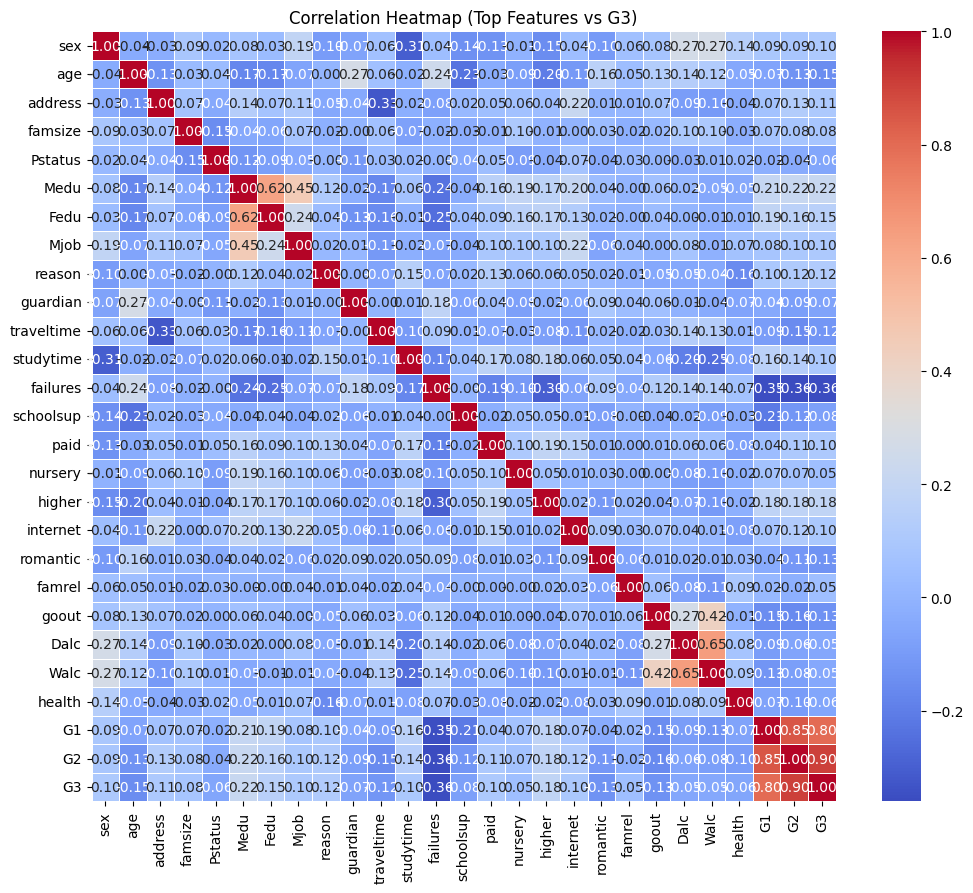

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

# Calculate correlation matrix
corr_matrix = df.corr()

# To keep the plot readable, let's only plot features that have at least some correlation with our target (G3)
top_features = corr_matrix.index[abs(corr_matrix['G3']) > 0.05]

sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap (Top Features vs G3)')
plt.show()

## 3. Train-Test Split & Scaling

In [11]:
from sklearn.model_selection import train_test_split

# Let's predict 'G3' (Final Grade). We drop G1 and G2 to prevent data leakage (they are highly correlated with G3).
X = df.drop(columns=['G3', 'G1', 'G2'])
y = df['G3']

# --- Apply Feature Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f'Training set size: {X_train.shape}')
print(f'Testing set size: {X_test.shape}')

Training set size: (316, 30)
Testing set size: (79, 30)


## 4. Build Linear Regression Model

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Generate Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
print('Model trained successfully!')

Model trained successfully!


## 5. Evaluate the Model

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, split_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f'--- {split_name} Performance ---')
    print(f'MAE:  {mae:.4f}')
    print(f'MSE:  {mse:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R²:   {r2:.4f}\n')

evaluate_model(y_train, y_train_pred, 'Training')
evaluate_model(y_test, y_test_pred, 'Testing')

--- Training Performance ---
MAE:  3.0313
MSE:  15.5034
RMSE: 3.9374
R²:   0.2619

--- Testing Performance ---
MAE:  3.5190
MSE:  18.6923
RMSE: 4.3235
R²:   0.0884



## 6. Regression Visualizations
To truly understand how our model is performing, we visualize its predictions and errors.

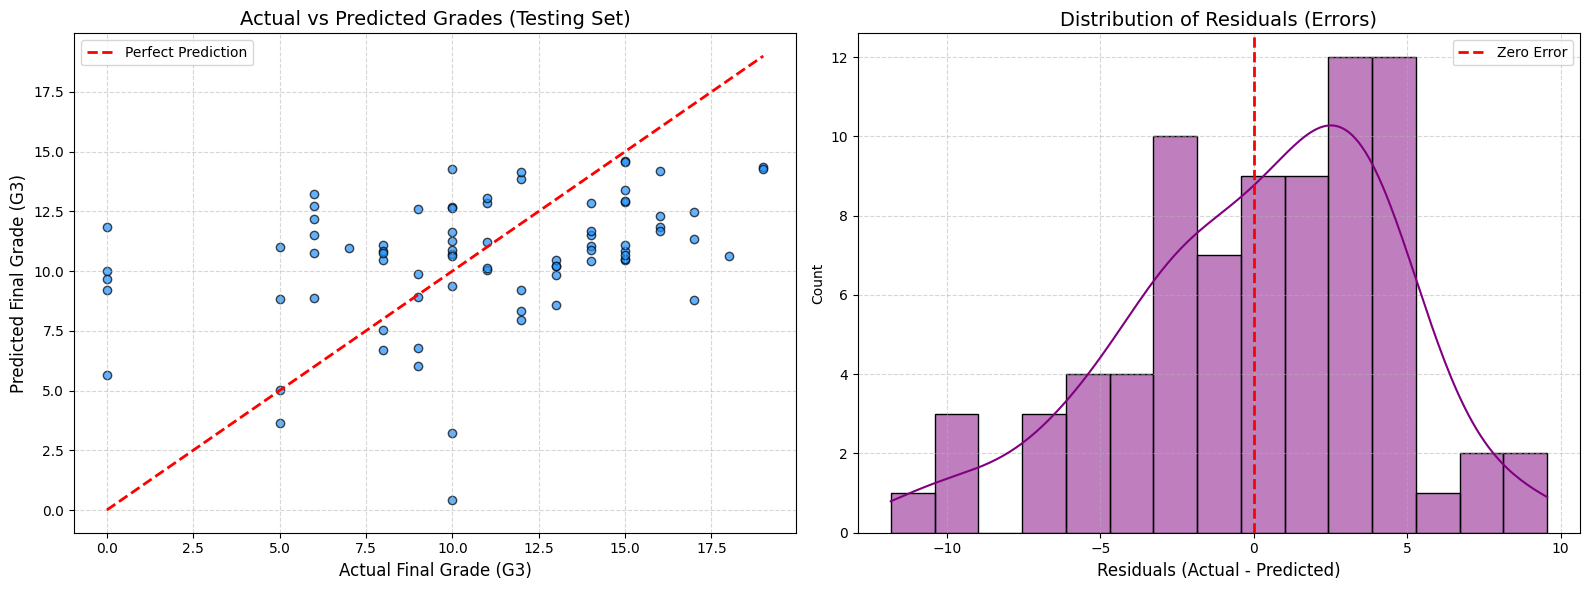

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted (Testing Set)
axes[0].scatter(y_test, y_test_pred, color='dodgerblue', alpha=0.7, edgecolors='k')
# Ideal prediction line (y = x)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Final Grade (G3)', fontsize=12)
axes[0].set_ylabel('Predicted Final Grade (G3)', fontsize=12)
axes[0].set_title('Actual vs Predicted Grades (Testing Set)', fontsize=14)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Residuals Distribution
residuals = y_test - y_test_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=15)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[1].set_xlabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_title('Distribution of Residuals (Errors)', fontsize=14)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 7. Analysis: Generalization vs Overfitting

By comparing the R² (and error metrics) between the **Training** and **Testing** sets, we can determine how well our model generalizes to new, unseen data.

- **Overfitting** occurs when a model performs exceptionally well on the training data (e.g., high R²) but poorly on the testing data (low or negative R²). This means the model memorized the noise in the training set instead of learning the underlying pattern.
- **Underfitting** occurs when the model performs poorly on both training and testing sets.
- **Generalization** occurs when the performance on the testing set is relatively close to the performance on the training set.

### Possible methods to reduce Overfitting:
1. **Feature Selection / Removing Irrelevant Variables:** Removing weak predictors ensures the model doesn't overcomplicate itself by trying to find patterns in useless noise.
2. **Cross-Validation:** Using k-fold cross-validation instead of a single train/test split provides a more robust estimate of model performance across different subsets.
3. **Regularization:** Algorithms like Ridge Regression (L2) or Lasso Regression (L1) penalize large coefficients, naturally shrinking the impact of irrelevant features.
4. **More Data:** Providing the model with more examples helps it distinguish true signal from noise.